In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files


uploaded = files.upload()

Saving social_media_engagement_5000.csv to social_media_engagement_5000.csv


In [4]:
# Load the uploaded CSV file
df = pd.read_csv("social_media_engagement_5000.csv")
df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [5]:
# Check data types of all columns
print(df.dtypes)

user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object


In [7]:
# Convert data type
df["posted_at"] = pd.to_datetime(df["posted_at"],errors="coerce")
print(df["posted_at"].dtype)

datetime64[ns]


In [8]:
# Convert columns into numpy arrays
likes_array = df["likes"].fillna(0).to_numpy()
comments_array = df["comments"].fillna(0).to_numpy()
shares_array = df["shares"].fillna(0).to_numpy()




In [9]:
# Basic array operations
total_likes = np.sum(likes_array)
mean_comments = np.mean(comments_array)
max_shares = np.max(shares_array)
print("total_likes:",total_likes)
print("mean_comments:",mean_comments)
print("max_shares:",max_shares)

total_likes: 49019162.0
mean_comments: 1457.1298
max_shares: 1999.0


In [10]:
# Data Cleaning

# Total count of missing values
print(df.isnull().sum())

user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64


In [11]:
# Handling missing values
# Numerical columns
df["age"] = df["age"].fillna(df["age"].median())
df["likes"] = df["likes"].fillna(df["likes"].median())
df["comments"] = df["comments"].fillna(df["comments"].median())
df["shares"] = df["shares"].fillna(df["shares"].median())

# Categorical columns
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])
df["sentiment"] = df["sentiment"].fillna(df["sentiment"].mode()[0])

# Alternative filling method
df = df.ffill().bfill()

# Alternative dropping method
df = df.dropna()

# Verify
print(df.isnull().sum())



user_id             0
age                 0
gender              0
country             0
post_id             0
post_type           0
post_category       0
likes               0
comments            0
shares              0
watch_time_sec      0
impression_count    0
posted_at           0
follower_count      0
is_verified         0
device_type         0
sentiment           0
hashtags            0
engagement_rate     0
dtype: int64


In [12]:
# Duplicate Handling
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0
0


In [13]:
# Data Formatting
df["age"] = df["age"].astype(int)
df["likes"] = df["likes"].astype(int)
df["comments"] = df["comments"].astype(int)
df["shares"] = df["shares"].astype(int)
print(df[["age","likes","comments","shares"]].dtypes)

age         int64
likes       int64
comments    int64
shares      int64
dtype: object


In [14]:
# Standardize gender labels
df["gender"] = df["gender"].astype(str).str.strip().str.capitalize()
print(df["gender"].unique())

['Female' 'Male' 'Other']


In [15]:
# Correct unrealistic values
df["likes"] = df["likes"].clip(lower=0)
df["comments"] = df["comments"].clip(lower=0)
df["shares"] = df["shares"].clip(lower=0)
print(df[["likes","comments","shares"]].describe())

              likes     comments     shares
count   5000.000000  5000.000000  5000.0000
mean   10106.982400  1502.039800  1002.9106
std     5702.293022   856.393312   570.8552
min       10.000000     0.000000     0.0000
25%     5235.000000   792.000000   511.0000
50%    10105.000000  1497.000000  1012.0000
75%    14959.000000  2235.250000  1483.0000
max    19998.000000  2999.000000  1999.0000


In [16]:
# Feature Cleaning
# Extract hashtag count
df["hashtag_count"] = df["hashtags"].str.count("#")
print(df["hashtag_count"])

0       3
1       1
2       1
3       3
4       1
       ..
4995    2
4996    2
4997    2
4998    3
4999    3
Name: hashtag_count, Length: 5000, dtype: int64


In [17]:
# Clean sentiment labels
df["sentiment"] = df["sentiment"].str.strip().str.capitalize().str.replace(":", "")
print(df["sentiment"].unique())

['Negative' 'Positive' 'Neutral']


In [18]:
# Data Exploration using Pandas
# View dataset structure
print(df.head())
print(df.tail())
print(df.shape)
print(df.columns)

   user_id  age  gender country  post_id post_type post_category  likes  \
0    25795   43  Female  Brazil   496713     image       fitness   7011   
1    10860   33    Male  Brazil   157326      reel          food  11750   
2    86820   32  Female      UK   109864      text          food   4862   
3    64886   51   Other  France   848877      text       fitness   5350   
4    16265   34   Other      UK   449706     image       fitness  12682   

   comments  shares  watch_time_sec  impression_count  posted_at  \
0       354    1157            5726             44650 2022-12-17   
1      2606    1807            5947             80216 2023-06-02   
2       344     955            6946             44858 2023-05-07   
3      1083    1049             229             70455 2023-02-12   
4      2735    1300            4798              6019 2023-05-23   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      mobile  Negative  #foodie

In [19]:
# Check data types and info
print(df.info())
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   int64         
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   int64         
 8   comments          5000 non-null   int64         
 9   shares            5000 non-null   int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [20]:
# Summary statistics
print(df.describe())

            user_id          age        post_id         likes     comments  \
count   5000.000000  5000.000000    5000.000000   5000.000000  5000.000000   
mean   54561.890800    38.440400  548042.909000  10106.982400  1502.039800   
min    10055.000000    13.000000  100068.000000     10.000000     0.000000   
25%    32309.500000    26.000000  322543.500000   5235.000000   792.000000   
50%    54374.500000    38.000000  548077.500000  10105.000000  1497.000000   
75%    77180.500000    51.000000  771574.500000  14959.000000  2235.250000   
max    99963.000000    64.000000  999455.000000  19998.000000  2999.000000   
std    26090.370121    14.687151  260646.957267   5702.293022   856.393312   

          shares  watch_time_sec  impression_count  \
count  5000.0000     5000.000000       5000.000000   
mean   1002.9106     4014.503200      50013.732800   
min       0.0000        0.000000        105.000000   
25%     511.0000     2017.750000      24988.250000   
50%    1012.0000     4034.5

In [21]:
# Categorical distributions
print(df["post_type"].value_counts())
print(df["gender"].unique())
print(df["post_category"].nunique)

post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64
['Female' 'Male' 'Other']
<bound method IndexOpsMixin.nunique of 0         fitness
1            food
2            food
3         fitness
4         fitness
          ...    
4995    education
4996    education
4997       travel
4998      fitness
4999       travel
Name: post_category, Length: 5000, dtype: object>


In [22]:
# Correlation matrix for numeric fields
print(df.select_dtypes(include=["number"]).corr())

                   user_id       age   post_id     likes  comments    shares  \
user_id           1.000000 -0.006688  0.020051  0.025811 -0.033395  0.013763   
age              -0.006688  1.000000 -0.013153 -0.036323 -0.007284  0.013871   
post_id           0.020051 -0.013153  1.000000  0.014526 -0.010540  0.001846   
likes             0.025811 -0.036323  0.014526  1.000000 -0.018421  0.004712   
comments         -0.033395 -0.007284 -0.010540 -0.018421  1.000000  0.006142   
shares            0.013763  0.013871  0.001846  0.004712  0.006142  1.000000   
watch_time_sec   -0.016847  0.005542  0.018374  0.008710 -0.016351  0.014658   
impression_count  0.015326  0.013322 -0.007709  0.007952 -0.009395 -0.005204   
follower_count    0.010124 -0.024894 -0.002844 -0.022982 -0.011733 -0.010783   
engagement_rate  -0.004282  0.008039  0.010139  0.093521  0.000051  0.021724   
hashtag_count    -0.013692  0.007173  0.007344 -0.002190 -0.015230  0.013379   

                  watch_time_sec  impre

In [23]:
# Groupby
print(df.groupby("post_type")["likes"].mean())
print(df.groupby("country")["impression_count"].mean())

post_type
image    10104.852446
reel     10037.784879
text     10100.132530
video    10188.586122
Name: likes, dtype: float64
country
Australia    48346.383367
Brazil       49193.174603
Canada       48703.150097
France       51727.673387
Germany      48605.406122
India        52462.386916
Japan        49616.135593
UAE          48928.413519
UK           51119.393509
USA          51263.872255
Name: impression_count, dtype: float64


In [24]:
# Data Wrangling
# Combine dataframe
df_concat=pd.concat([df,df],ignore_index=True)
print(df_concat.shape)

df_additional=pd.DataFrame({"user_id": df["user_id"].unique(),
                            "subscription_status":"Active"})
df_joined = df.set_index("user_id").join(df_additional.set_index("user_id"),how="left")
print(df_joined.head())

(10000, 20)
         age  gender country  post_id post_type post_category  likes  \
user_id                                                                
25795     43  Female  Brazil   496713     image       fitness   7011   
10860     33    Male  Brazil   157326      reel          food  11750   
86820     32  Female      UK   109864      text          food   4862   
64886     51   Other  France   848877      text       fitness   5350   
16265     34   Other      UK   449706     image       fitness  12682   

         comments  shares  watch_time_sec  impression_count  posted_at  \
user_id                                                                  
25795         354    1157            5726             44650 2022-12-17   
10860        2606    1807            5947             80216 2023-06-02   
86820         344     955            6946             44858 2023-05-07   
64886        1083    1049             229             70455 2023-02-12   
16265        2735    1300            47

In [25]:
# Create new feature fields
df["engagement_score"] = (df["likes"]+df["comments"]*2+df["shares"]*3/df["impression_count"])
df["log_likes"] = np.log1p(df["likes"])
df["hashtag_count"] = df["post_caption"].str.count("#")if "post_caption" in df.columns else 0
print(df[["engagement_score","log_likes","hashtag_count"]].head())

   engagement_score  log_likes  hashtag_count
0       7719.077738   8.855378              0
1      16962.067580   9.371694              0
2       5550.063868   8.489411              0
3       7516.044667   8.585039              0
4      18152.647948   9.448018              0


In [26]:
# Groupby
df_summary = df.groupby(["post_type","country","sentiment"]).agg(mean_likes=("likes","mean"),
                                                                total_shares=("shares","sum"),
                                                                 avg_watch_time=("watch_time_sec","mean")
).reset_index()
print(df_summary.head())

  post_type    country sentiment    mean_likes  total_shares  avg_watch_time
0     image  Australia  Negative   8006.105263         18897     3534.000000
1     image  Australia   Neutral   9683.666667         48588     4132.190476
2     image  Australia  Positive  10234.696970         70979     4097.651515
3     image     Brazil  Negative   7559.350000         20201     4401.200000
4     image     Brazil   Neutral   8409.608696         51799     4092.826087


In [27]:
# Statistical Analysis
existing_metrics = ["likes","comments","shares","watch_time_sec","engagement_score","follower_count"]

status_summary = pd.DataFrame({
    "mean":df[existing_metrics].mean(),
    "median":df[existing_metrics].median(),
    "mode":df[existing_metrics].mode().iloc[0]
})
print(status_summary)


                          mean         median           mode
likes              10106.98240   10105.000000   10105.000000
comments            1502.03980    1497.000000    1497.000000
shares              1002.91060    1012.000000    1012.000000
watch_time_sec      4014.50320    4034.500000     916.000000
engagement_score   13111.29653   13051.013892     245.037673
follower_count    393698.22480  388982.000000  497502.000000


In [28]:
# S/D & Variance
dispersion_summary=pd.DataFrame({"std":df[existing_metrics].std(),
                                 "variance":df[existing_metrics].var()})
print(dispersion_summary)

                            std      variance
likes               5702.293022  3.251615e+07
comments             856.393312  7.334095e+05
shares               570.855200  3.258757e+05
watch_time_sec      2308.096459  5.327309e+06
engagement_score    5923.685673  3.509005e+07
follower_count    230927.884535  5.332769e+10


In [29]:
# Percentiles
percentiles_summary=df[existing_metrics].quantile([0.25,0.5,0.75])
print(percentiles_summary)

        likes  comments  shares  watch_time_sec  engagement_score  \
0.25   5235.0    792.00   511.0         2017.75       8292.610401   
0.50  10105.0   1497.00  1012.0         4034.50      13051.013892   
0.75  14959.0   2235.25  1483.0         6020.25      17858.835057   

      follower_count  
0.25       194480.00  
0.50       388982.00  
0.75       589744.25  


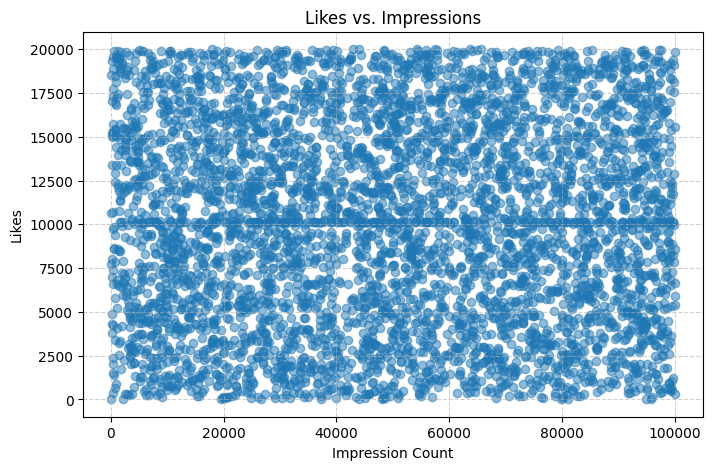

In [43]:
# Data Visualization
# Matplotlib
# Scatter chart

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(df["impression_count"],df["likes"],alpha=0.5)
plt.title("Likes vs. Impressions")
plt.xlabel("Impression Count")
plt.ylabel("Likes")
plt.grid(True,linestyle="--",alpha=0.6)
plt.show()

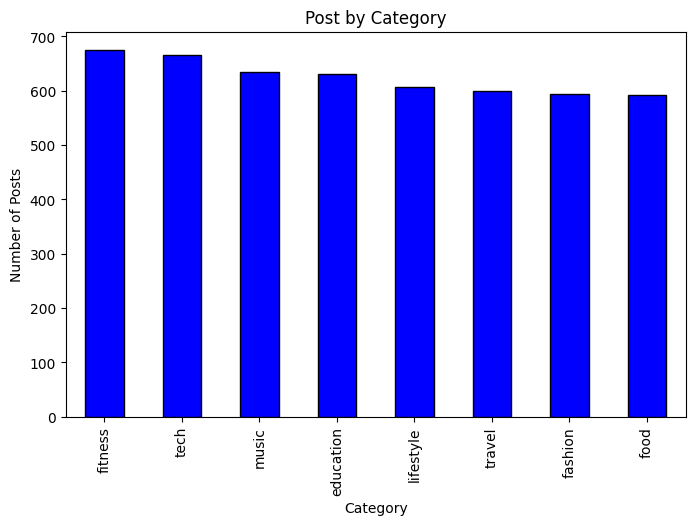

In [31]:
# Bar chart
category_count=df["post_category"].value_counts()
plt.figure(figsize=(8,5))
category_count.plot(kind="bar",color="blue",edgecolor="black")
plt.title("Post by Category")
plt.xlabel("Category")
plt.ylabel("Number of Posts")
plt.show()

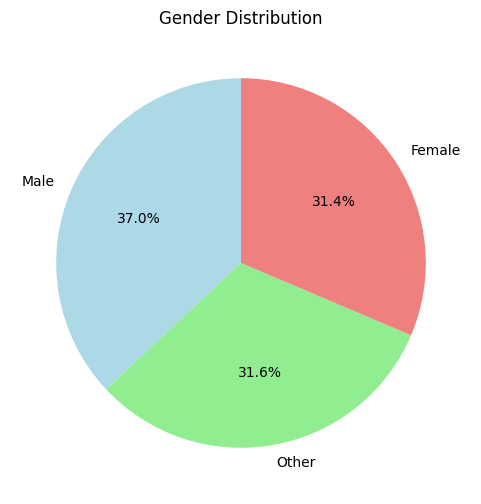

In [32]:
# Pie chart
gender_counts=df["gender"].value_counts()
plt.figure(figsize=(6,6))
gender_counts.plot(kind="pie",autopct="%1.1f%%",startangle=90,colors=["lightblue","lightgreen","lightcoral"])
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

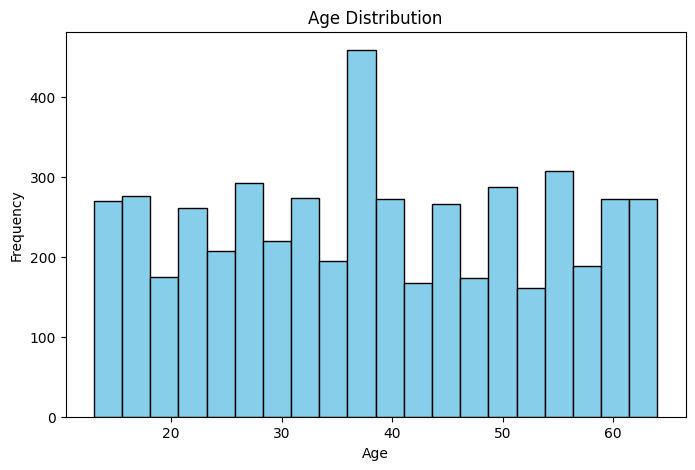

In [33]:
# Histogram
plt.figure(figsize=(8,5))
plt.hist(df["age"].dropna(),bins=20,color="skyblue",edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

country
Australia    1.324339
Brazil       1.540704
Canada       0.916659
France       1.146402
Germany      0.759000
India        0.655005
Japan        0.769623
UAE          1.112352
UK           0.850966
USA          0.576580
Name: engagement_rate, dtype: float64


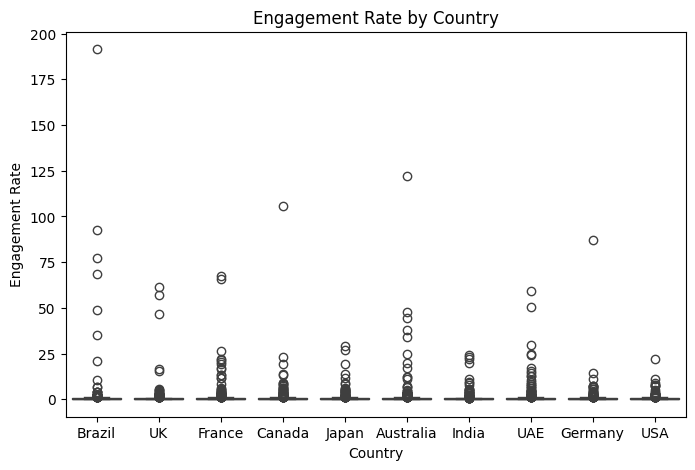

In [42]:
# Box Plot
# calculate the average engagement rate
country_engagement_rate=df.groupby("country")["engagement_rate"].mean()
print(country_engagement_rate)

# Create a box plot
plt.figure(figsize=(8,5))
sns.boxplot(x="country",y="engagement_rate",data=df)
plt.title("Engagement Rate by Country")
plt.xlabel("Country")
plt.ylabel("Engagement Rate")
plt.show()

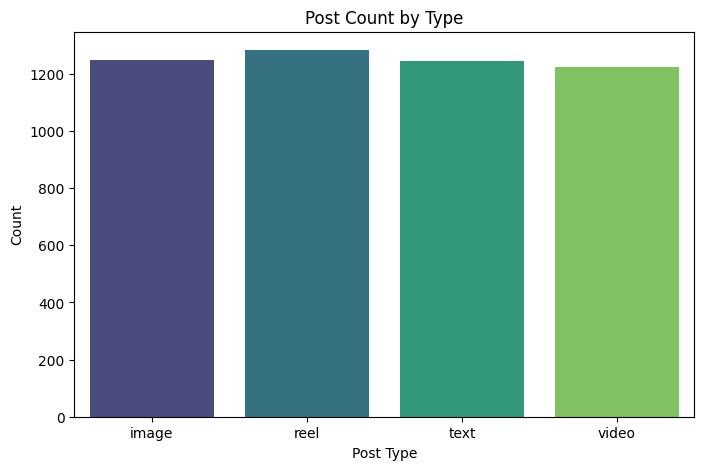

In [35]:
# Seaborn
# Count Plot
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="post_type",hue="post_type",palette="viridis",legend=False)
plt.title("Post Count by Type")
plt.xlabel("Post Type")
plt.ylabel("Count")
plt.show()

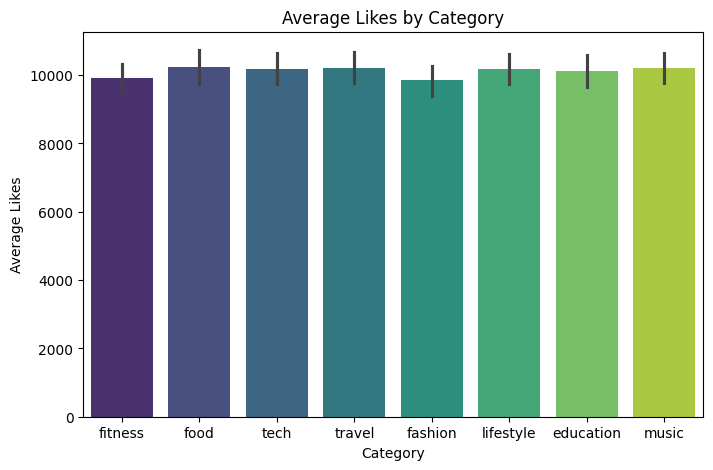

In [36]:
# Bar Plot
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="post_category",y="likes",hue="post_category",palette="viridis",legend=False)
plt.title("Average Likes by Category")
plt.xlabel("Category")
plt.ylabel("Average Likes")
plt.show()

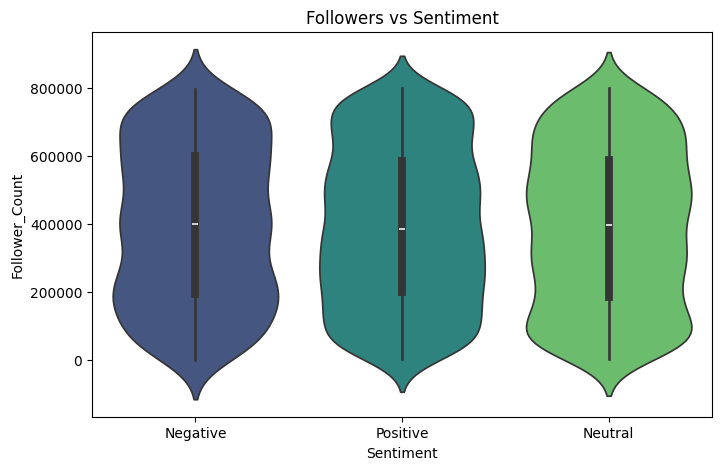

In [37]:
# Violin
plt.figure(figsize=(8,5))
sns.violinplot(data=df,x="sentiment",y="follower_count",hue="sentiment",palette="viridis",legend=False)
plt.title("Followers vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Follower_Count")
plt.show()

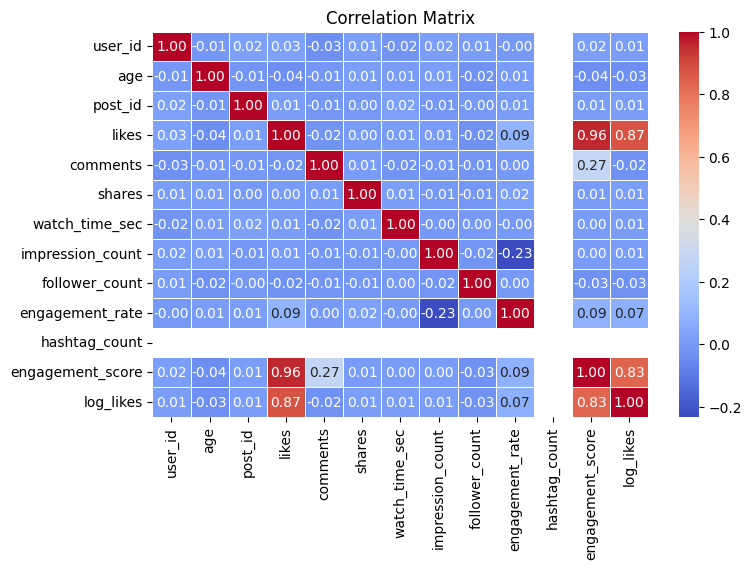

In [38]:
# Heatmap
plt.figure(figsize=(8,5))
correlation_matrix=df.select_dtypes(include=["number"]).corr()
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [40]:
# Plotly
import plotly.express as px
# Interactive Line Chart
# Aggregate daily average  likes
df["posted_at"]=pd.to_datetime(df["posted_at"])
daily_df=df.groupby(df["posted_at"].dt.date)["likes"].mean().reset_index()

# Create line chart
fig_line=px.line(daily_df,x="posted_at",y="likes",title="Daily Average Likes Trend",
                 labels={"posted_at":"date","likes":"average likes"},)

fig_line.show()



# **Final** **Insights**

---

### *Content Performance*








*   Reels achieve the highest volume of post distribution and are closely matched by video content,showing that dynamic media  drives consistent engagement across users.
*   Food leads as the best-performing content category with the highest average likes,closely followed by music,travel,and tech.


*   Brazil leads all regions with the highest average engagement rate and is closely followed by Australia.

### *User Trends*


*   Younger demographics and digital-native age segments consistently demonstrate higher interaction levels and responsiveness to social content compared to older groups.
*   Audiences tend to exhibit higher trust in verified badges,which frequently translates to increased likes,comments,and overall interaction rates.

### Behavioral Insights


*   Mobile devices drive the vast majority of total watch time due to constant accessibility and mobile-first browsing habits.
*   Tablets and desktops capture longer continuous watch times per individual session.

### Sentiment Analysis


*   Positive sentiment posts drive the highest overall engagement rates and conversion metrics.
*   Negative sentiment content often triggers higher comment volumes driven by debate or controversy.Neutral posts experience steady,passive consumption patterns with minimal spikes in likes or shares.










